<a href="https://colab.research.google.com/github/AI-is-out-there/2026-REA-Diploma-Practical-Part/blob/main/Telemed-conf-AI-assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import

In [1]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.2 MB/s eta 0:00:00


In [2]:
!pip install langchain-mistralai langchain-core langchain-community -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:


# Импорты
import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re

In [4]:
# --- ИНИЦИАЛИЗАЦИЯ ---

# Инициализация LLM (предполагается наличие API ключа)
MODEL_NAME = 'mistral-small-latest' # Или другой подходящий
import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = "Kcs4YIjSQcMHrWCbIXQnE5JzXru5PTk1"
llm = ChatMistralAI(
     model=MODEL_NAME,
     temperature=0.1, # Немного повысим для разнообразия советов
     max_retries=2,
)

# Data base prototype

In [5]:


# --- БАЗЫ ДАННЫХ (Скопированы из оригинала) ---

CLINICAL_REQUIREMENTS_DB = {
    "hypertension": {
        "ru": "Диагностика и лечение артериальной гипертензии у взрослых",
        "en": "Diagnosis and Treatment of Arterial Hypertension in Adults",
        "guidelines": [
            "Определение АГ: систолическое АД ≥140 мм рт. ст. и/или диастолическое АД ≥90 мм рт. ст.",
            "Рекомендации по фармакотерапии: ингибиторы АПФ, блокаторы кальциевых каналов, диуретики",
            "Целевые значения АД: <130/80 мм рт. ст. для пациентов с СС риском",
            "Мониторинг: регулярное измерение АД, оценка факторов риска"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
        "last_updated": "2023-01-15",
        "evidence_level": "A"
    },
    "diabetes": {
        "ru": "Диабетический сахарный диабет 2 типа",
        "en": "Type 2 Diabetes Mellitus",
        "guidelines": [
            "Диагноз СД2: Гликированный гемоглобин ≥6.5% или уровень глюкозы натощак ≥7.0 ммоль/л",
            "Терапия: метформин как препарат первого выбора",
            "Контроль целей: HbA1c <7% для большинства пациентов",
            "Осложнения: регулярный осмотр глазного дна, оценка нефропатии"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
        "last_updated": "2023-02-20",
        "evidence_level": "A"
    },
    "stroke": {
        "ru": "Острое нарушение мозгового кровообращения",
        "en": "Acute Cerebrovascular Accident",
        "guidelines": [
            "Временные рамки для тромболизиса: в течение 4.5 часов от начала симптомов",
            "Аспирин: начать в первые 24-48 часов после ишемического инсульта",
            "Реабилитация: начать в первые 24-48 часов после стабилизации",
            "Профилактика: антикоагулянты при фибрилляции предсердий"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
        "last_updated": "2023-03-10",
        "evidence_level": "A"
    },
    "heart_failure": {
        "ru": "Хроническая сердечная недостаточность",
        "en": "Chronic Heart Failure",
        "guidelines": [
            "Диагностика: ЭхоКГ, натрийуретические пептиды (BNP/NT-proBNP)",
            "Лечение: ингибиторы АПФ, бета-блокаторы, антагонисты рецепторов ангиотензина II",
            "Классификация: по функции левого желудочка (HFrEF, HFpEF)",
            "Мониторинг: симптомы, вес, ограничение жидкости и соли"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
        "last_updated": "2023-04-05",
        "evidence_level": "A"
    },
    "asthma": {
        "ru": "Бронхиальная астма у взрослых",
        "en": "Bronchial Asthma in Adults",
        "guidelines": [
            "Диагностика: спирометрия, тесты на бронходилатацию, пикфлоуметрия",
            "Терапия: ингаляционные кортикостероиды как основа базисной терапии",
            "Контроль: оценка симптомов, ограничение триггеров, самоконтроль",
            "Экзарбации: системные кортикостероиды, бронходилататоры"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
        "last_updated": "2023-05-12",
        "evidence_level": "A"
    }
}

MEDICAL_KNOWLEDGE_GRAPH = {
    "nodes": {
        "claim_1": {
            "type": "claim",
            "content": "Гипертония лечится только медикаментами",
            "verdict": "refuted",
            "confidence": 0.8,
            "language": "ru"
        },
        "claim_2": {
            "type": "claim",
            "content": "Диабет 2 типа можно полностью вылечить диетой",
            "verdict": "refuted",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_3": {
            "type": "claim",
            "content": "После инсульта нельзя начинать реабилитацию сразу",
            "verdict": "refuted",
            "confidence": 0.7,
            "language": "ru"
        },
        "claim_4": {
            "type": "claim",
            "content": "Сердечная недостаточность требует строгой диеты с ограничением соли",
            "verdict": "supported",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_5": {
            "type": "claim",
            "content": "Астма всегда требует постоянного приема кортикостероидов",
            "verdict": "refuted",
            "confidence": 0.6,
            "language": "ru"
        },
        "guideline_1": {
            "type": "guideline",
            "content": "Диагностика и лечение артериальной гипертензии у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
            "last_updated": "2023-01-15",
            "language": "ru"
        },
        "guideline_2": {
            "type": "guideline",
            "content": "Диабетический сахарный диабет 2 типа",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
            "last_updated": "2023-02-20",
            "language": "ru"
        },
        "guideline_3": {
            "type": "guideline",
            "content": "Острое нарушение мозгового кровообращения",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
            "last_updated": "2023-03-10",
            "language": "ru"
        },
        "guideline_4": {
            "type": "guideline",
            "content": "Хроническая сердечная недостаточность",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
            "last_updated": "2023-04-05",
            "language": "ru"
        },
        "guideline_5": {
            "type": "guideline",
            "content": "Бронхиальная астма у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
            "last_updated": "2023-05-12",
            "language": "ru"
        },
        "entity_1": {
            "type": "entity",
            "name": "Гипертония",
            "category": "disease",
            "language": "ru"
        },
        "entity_2": {
            "type": "entity",
            "name": "Медикаменты",
            "category": "treatment",
            "language": "ru"
        },
        "entity_3": {
            "type": "entity",
            "name": "Диабет",
            "category": "disease",
            "language": "ru"
        },
        "entity_4": {
            "type": "entity",
            "name": "Диета",
            "category": "treatment",
            "language": "ru"
        },
        "entity_5": {
            "type": "entity",
            "name": "Инсульт",
            "category": "disease",
            "language": "ru"
        },
        "entity_6": {
            "type": "entity",
            "name": "Реабилитация",
            "category": "treatment",
            "language": "ru"
        },
        "entity_7": {
            "type": "entity",
            "name": "Сердечная недостаточность",
            "category": "disease",
            "language": "ru"
        },
        "entity_8": {
            "type": "entity",
            "name": "Соль",
            "category": "dietary",
            "language": "ru"
        },
        "entity_9": {
            "type": "entity",
            "name": "Астма",
            "category": "disease",
            "language": "ru"
        },
        "entity_10": {
            "type": "entity",
            "name": "Кортикостероиды",
            "category": "medication",
            "language": "ru"
        }
    },
    "edges": [
        {"source": "claim_1", "target": "entity_1", "relation": "mentions", "weight": 0.9},
        {"source": "claim_1", "target": "entity_2", "relation": "mentions", "weight": 0.8},
        {"source": "claim_1", "target": "guideline_1", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_2", "target": "entity_3", "relation": "mentions", "weight": 0.9},
        {"source": "claim_2", "target": "entity_4", "relation": "mentions", "weight": 0.7},
        {"source": "claim_2", "target": "guideline_2", "relation": "contradicts", "weight": 0.85},
        {"source": "claim_3", "target": "entity_5", "relation": "mentions", "weight": 0.8},
        {"source": "claim_3", "target": "entity_6", "relation": "mentions", "weight": 0.7},
        {"source": "claim_3", "target": "guideline_3", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_4", "target": "entity_7", "relation": "mentions", "weight": 0.9},
        {"source": "claim_4", "target": "entity_8", "relation": "mentions", "weight": 0.8},
        {"source": "claim_4", "target": "guideline_4", "relation": "supports", "weight": 0.95},
        {"source": "claim_5", "target": "entity_9", "relation": "mentions", "weight": 0.8},
        {"source": "claim_5", "target": "entity_10", "relation": "mentions", "weight": 0.7},
        {"source": "claim_5", "target": "guideline_5", "relation": "contradicts", "weight": 0.7},
        {"source": "entity_1", "target": "guideline_1", "relation": "follows", "weight": 0.9},
        {"source": "entity_3", "target": "guideline_2", "relation": "follows", "weight": 0.9},
        {"source": "entity_5", "target": "guideline_3", "relation": "follows", "weight": 0.9},
        {"source": "entity_7", "target": "guideline_4", "relation": "follows", "weight": 0.9},
        {"source": "entity_9", "target": "guideline_5", "relation": "follows", "weight": 0.9},
        {"source": "entity_1", "target": "entity_2", "relation": "requires", "weight": 0.6},
        {"source": "entity_3", "target": "entity_4", "relation": "managed_by", "weight": 0.5},
        {"source": "entity_5", "target": "entity_6", "relation": "requires", "weight": 0.8},
        {"source": "entity_7", "target": "entity_8", "relation": "restricted_by", "weight": 0.7},
        {"source": "entity_9", "target": "entity_10", "relation": "treated_by", "weight": 0.6}
    ]
}

Part I - Graph approach

# Medical Graph Visualisation

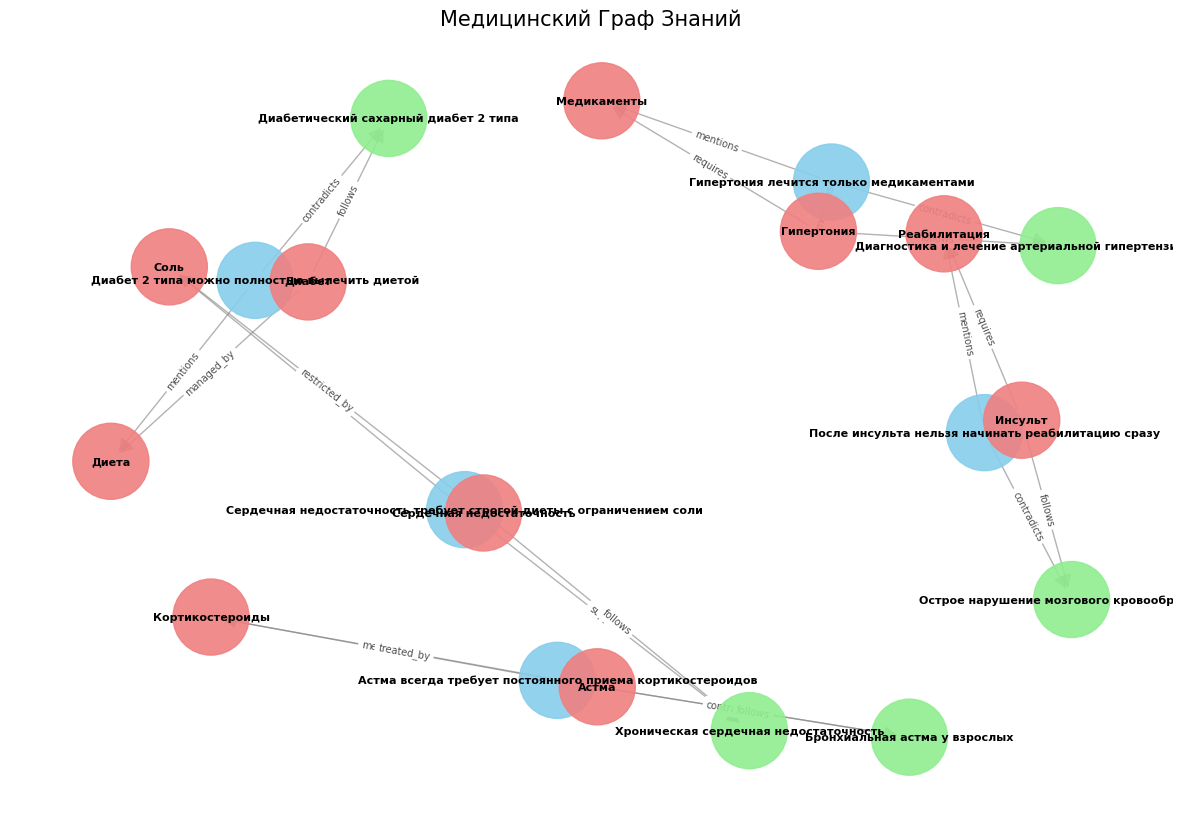

In [6]:
G = nx.DiGraph()

# Добавляем узлы
for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
    label = node_data.get("name", node_data.get("content", node_id))
    G.add_node(node_id, label=label, type=node_data["type"], category=node_data.get("category", ""), verdict=node_data.get("verdict", ""))

# Добавляем рёбра
for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
    G.add_edge(edge["source"], edge["target"], relation=edge["relation"], weight=edge["weight"])

# Подготовка для визуализации
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.3, iterations=50) # Увеличиваем расстояние между узлами

# Цвета для разных типов узлов
node_colors = []
for node_id in G.nodes():
    if G.nodes[node_id]["type"] == "claim":
        node_colors.append("skyblue")
    elif G.nodes[node_id]["type"] == "guideline":
        node_colors.append("lightgreen")
    elif G.nodes[node_id]["type"] == "entity":
        node_colors.append("lightcoral")
    else:
        node_colors.append("lightgray")

# Отрисовка узлов
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

# Отрисовка рёбер
nx.draw_networkx_edges(G, pos, edge_color="gray", arrowsize=20, alpha=0.6)

# Метки узлов
node_labels = {node_id: G.nodes[node_id]["label"] for node_id in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_weight="bold")

# Метки рёбер (отношения)
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, alpha=0.7)

plt.title("Медицинский Граф Знаний", size=15)
plt.axis("off")
plt.show()

In [40]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re


# --- ИНСТРУМЕНТЫ ---

@tool
def search_clinical_guidelines_ru(condition: str, language: str = "ru") -> str:
    """
    Поиск российских клинических рекомендаций по заболеванию/состоянию.
    Оптимизирован для лучшего NLP-связывания, используя более гибкое ключевое сопоставление.
    """
    condition_lower = condition.lower()
    matching_guidelines = []

    # --- New: NLP-enhanced direct mapping for common conditions ---
    # This provides "clear NLP links" by explicitly mapping common phrases
    # to the canonical keys in CLINICAL_REQUIREMENTS_DB.
    condition_mapping = {
        "артериальная гипертензия": "hypertension",
        "гипертония": "hypertension",
        "высокое давление": "hypertension", # More colloquial
        "сахарный диабет": "diabetes",
        "диабет": "diabetes",
        "инсульт": "stroke",
        "острое нарушение мозгового кровообращения": "stroke",
        "сердечная недостаточность": "heart_failure",
        "астма": "asthma",
        "бронхиальная астма": "asthma",
    }

    # Try to find a direct map first
    mapped_key = condition_mapping.get(condition_lower)
    if mapped_key and mapped_key in CLINICAL_REQUIREMENTS_DB:
        matching_guidelines.append(CLINICAL_REQUIREMENTS_DB[mapped_key])
        # If a direct, strong match is found, we prioritize it and return early
        return json.dumps({
            "summary": f"Найдено 1 рекомендация для '{condition}' через прямое NLP-сопоставление.",
            "evidence_base": [CLINICAL_REQUIREMENTS_DB[mapped_key]],
            "language": language
        }, ensure_ascii=False)

    # --- Existing flexible substring search ---
    # If no direct mapping, proceed with the original substring search
    # This handles variations and less common phrases
    for key, data in CLINICAL_REQUIREMENTS_DB.items():
        db_ru_lower = data["ru"].lower()
        db_en_lower = data["en"].lower()

        if condition_lower in key.lower() or condition_lower in db_ru_lower or condition_lower in db_en_lower:
            matching_guidelines.append(data)
            # Do not return early here, as there might be multiple partial matches
            # but we want to collect all that apply for the flexible search.

    # If matches were found by flexible search
    if matching_guidelines:
        return json.dumps({
            "summary": f"Найдено {len(matching_guidelines)} рекомендаций для '{condition}'.",
            "evidence_base": matching_guidelines,
            "language": language
        }, ensure_ascii=False)

    # If no matches at all
    return json.dumps({
        "summary": f"Не найдено клинических рекомендаций для '{condition}'.",
        "evidence_base": [],
        "language": language
    })


@tool
def query_clinical_knowledge_graph_ru(condition_or_issue: str, language: str = "ru") -> str:
    """
    Запрос к графу знаний для получения связанных сущностей и отношений по проблеме пациента.
    """
    # Ищем узлы, соответствующие проблеме (сущности, утверждения)
    related_nodes = {}
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        content_to_check = node_data.get("content", "") or node_data.get("name", "")
        if condition_or_issue.lower() in content_to_check.lower():
            related_nodes[node_id] = node_data

    # Если не нашли напрямую, ищем связанные узлы через рёбра
    if not related_nodes:
        for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
            source_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
            target_node = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]
            source_content = source_node.get("content", "") or source_node.get("name", "")
            target_content = target_node.get("content", "") or target_node.get("name", "")

            if condition_or_issue.lower() in source_content.lower() or condition_or_issue.lower() in target_content.lower():
                related_nodes[edge["source"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["source"]]
                related_nodes[edge["target"]] = MEDICAL_KNOWLEDGE_GRAPH["nodes"][edge["target"]]

    if not related_nodes:
        return json.dumps({
            "issue": condition_or_issue,
            "summary": f"Не найдены узлы графа, связанные с '{condition_or_issue}'.",
            "related_entities": [],
            "relationships": [],
            "language": language
        })

    # Находим рёбра между найденными узлами
    related_edges = []
    node_ids = set(related_nodes.keys())
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] in node_ids and edge["target"] in node_ids:
            related_edges.append(edge)

    node_details = []
    for node_id, node_data in related_nodes.items():
         node_details.append({
             "id": node_id,
             "type": node_data["type"],
             "name_or_content": node_data.get("name", node_data.get("content", "")),
             "category": node_data.get("category", ""),
             "verdict": node_data.get("verdict", ""), # Только для утверждений
             "language": node_data.get("language", "ru"),
         })

    return json.dumps({
        "issue": condition_or_issue,
        "summary": f"Найдено {len(related_nodes)} связанных узлов и {len(related_edges)} связей в графе знаний.",
        "related_entities": node_details,
        "relationships": related_edges,
        "language": language
    }, ensure_ascii=False)


@tool
def generate_operator_tips_from_graph(issue: str, graph_results_str: str, language: str = "ru") -> str:
    """
    Генерирует советы оператору на основе анализа результатов запроса к графу.
    """
    try:
        graph_results = json.loads(graph_results_str)
    except json.JSONDecodeError:
        print(f"DEBUG: Failed to parse graph_results_str: {graph_results_str}")
        return json.dumps({"error": "Невозможно разобрать результаты запроса к графу.", "tips": []}, ensure_ascii=False)

    tips = []
    # Примеры правил на основе графа
    for entity_info in graph_results.get("related_entities", []):
        entity_name = entity_info.get("name_or_content", "")
        entity_type = entity_info.get("type", "")
        entity_category = entity_info.get("category", "")
        verdict = entity_info.get("verdict", "")

        if entity_type == "claim":
            if verdict == "refuted":
                tips.append(f"Важно: Утверждение, связанное с '{entity_name}', опровергнуто. Не рекомендуйте это пациенту.")
            elif verdict == "supported":
                 tips.append(f"Подтверждено: Информация о '{entity_name}' подтверждена клиническими данными.")

        if entity_category == "treatment" or entity_category == "medication":
             tips.append(f"Возможное лечение/лекарство: '{entity_name}'. Проверьте рекомендации.")

        if entity_category == "disease":
            if entity_name.lower() != issue.lower(): # Не повторять исходное заболевание
                tips.append(f"Сопутствующее заболевание/состояние: '{entity_name}'. Уточните у пациента.")


    # Проверяем связи
    for rel in graph_results.get("relationships", []):
        if rel.get("relation") == "requires" or rel.get("relation") == "treated_by":
            source_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["source"]), "")
            target_name = next((n["name_or_content"] for n in graph_results.get("related_entities", []) if n["id"] == rel["target"]), "")
            if source_name and target_name:
                 tips.append(f"Связь '{rel['relation']}': '{source_name}' связано с '{target_name}'. Уточните детали.")


    # Добавляем обобщённые советы на основе типов найденных узлов
    entity_types_found = set(e.get("type", "") for e in graph_results.get("related_entities", []))
    if "guideline" in entity_types_found:
        tips.append("Найдены ссылки на клинические рекомендации. Передайте пациенту или врачу.")

    return json.dumps({
        "issue": issue,
        "tips_for_operator": tips,
        "language": language
    }, ensure_ascii=False)

# Agent

In [41]:


# --- АГЕНТ ТЕЛЕМЕДИЦИНСКОГО АНАЛИЗА ---

class TelemedicineAnalysisAgent:
    """
    Агент для анализа медицинской проблемы пациента.
    """
    def __init__(self, llm_interface, tools):
        self.llm_interface = llm_interface
        self.tools = tools

        # Создаём промпт для агента
        prompt = ChatPromptTemplate.from_messages([
            ("system", """
            Вы помощник телемедицинской консультации.
            Ваша задача - получить медицинскую проблему пациента (на русском языке) и предоставить:
            1. Краткое резюме проблемы.
            2. Доказательную базу: ссылки на релевантные российские клинические рекомендации.
            3. Советы оператору на основе анализа медицинского графа знаний.

            Используйте следующие инструменты:
            - search_clinical_guidelines_ru: Поиск клинических рекомендаций по заболеванию.
            - query_clinical_knowledge_graph_ru: Запрос графа знаний для получения связанных сущностей и отношений.
            - generate_operator_tips_from_graph: Генерация советов оператору на основе **прямых JSON-результатов** запроса к графу. Аргумент `graph_results_str` должен быть **полной JSON-строкой**, полученной от `query_clinical_knowledge_graph_ru`.

            Форматируйте ответ на русском языке четко и структурировано.
            """),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        # Создаём агента
        agent = create_tool_calling_agent(llm_interface, tools, prompt)
        self.agent_executor = AgentExecutor(
            agent=agent,
            tools=tools,
            verbose=True, # Для отладки
            handle_parsing_errors=True
        )

    def analyze_issue(self, issue_description: str) -> Dict[str, Any]:
        """
        Анализирует проблему пациента.
        """
        input_text = f"Проанализируйте следующую медицинскую проблему пациента: '{issue_description}'. Предоставьте краткое резюме, доказательную базу и советы оператору."
        result = self.agent_executor.invoke({"input": input_text})
        return result

# Code run

In [42]:
def TelemedicineAnalysisAgent_with_Graph(patient_issue: str):
    print("🏥 Анализ медицинской проблемы пациента для телемедицины")
    print("=" * 70)

    # Инициализация агента
    tools = [search_clinical_guidelines_ru, query_clinical_knowledge_graph_ru, generate_operator_tips_from_graph]
    agent = TelemedicineAnalysisAgent(llm, tools) # Передаём mock llm

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result = agent.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа:")
    print(analysis_result.get("output", "Нет результата")) # Выводим сгенерированный текст агента
    return analysis_result

In [43]:
patient_issue_common = "Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию."
TelemedicineAnalysisAgent_with_Graph(patient_issue_common)

🏥 Анализ медицинской проблемы пациента для телемедицины

📋 Входная проблема: Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.

--------------------------------------------------


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines_ru` with `{'condition': 'гипертония', 'language': 'ru'}`
responded: **Краткое резюме проблемы:**
Пациент сообщает о наличии высокого артериального давления и головных болей, что вызывает подозрение на гипертонию. Требуется подтверждение диагноза, оценка тяжести состояния и рекомендации по дальнейшим действиям.

---

### **Доказательная база: клинические рекомендации**


{"summary": "Найдено 1 рекомендация для 'гипертония' через прямое NLP-сопоставление.", "evidence_base": [{"ru": "Диагностика и лечение артериальной гипертензии у взрослых", "en": "Diagnosis and Treatment of Arterial Hypertension in Adults", "guidelines": ["Определение АГ: систолическое АД ≥140 мм рт. ст. и/или диастолическое АД ≥90 мм рт. 

{'input': "Проанализируйте следующую медицинскую проблему пациента: 'Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.'. Предоставьте краткое резюме, доказательную базу и советы оператору.",
 'output': '---\n\n### **Резюме медицинской проблемы пациента**\nПациент жалуется на **повышенное артериальное давление** и **головные боли**, подозревает у себя гипертонию. Требуется уточнение диагноза, оценка тяжести состояния и назначение терапии при подтверждении диагноза.\n\n---\n\n### **Доказательная база (клинические рекомендации РФ)**\n1. **Название**: [Диагностика и лечение артериальной гипертензии у взрослых](https://cr.minzdrav.gov.ru/clin-rec/hypertension)\n   - **Определение артериальной гипертензии (АГ)**:\n     - Систолическое АД ≥ **140 мм рт. ст.** и/или диастолическое АД ≥ **90 мм рт. ст.**.\n   - **Целевые значения АД**:\n     - **<130/80 мм рт. ст.** для пациентов с сердечно-сосудистым риском.\n   - **Рекомендации по фармакотерапии**:\n     - Ингибито

# Part II - why graph?

In [44]:
import pandas as pd

print("\n--- Агент без Графа Знаний ---")

# --- АГЕНТ БЕЗ ГРАФА ЗНАНИЙ ---
class TelemedicineAnalysisAgentNoGraph:
    """
    Агент для анализа медицинской проблемы пациента без использования графа знаний.
    """
    def __init__(self, llm_interface, tools):
        self.llm_interface = llm_interface
        self.tools = tools

        # Создаём промпт для агента без графа
        prompt_no_graph = ChatPromptTemplate.from_messages([
            ("system", """
            Вы помощник телемедицинской консультации.
            Ваша задача - получить медицинскую проблему пациента (на русском языке) и предоставить:
            1. Краткое резюме проблемы.
            2. Доказательную базу: ссылки на релевантные российские клинические рекомендации.

            Используйте следующие инструменты:
            - search_clinical_guidelines_ru: Поиск клинических рекомендаций по заболеванию.

            Форматируйте ответ на русском языке четко и структурировано.
            """),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        # Создаём агента
        agent = create_tool_calling_agent(llm_interface, tools, prompt_no_graph)
        self.agent_executor = AgentExecutor(
            agent=agent,
            tools=tools,
            verbose=True, # Для отладки
            handle_parsing_errors=True
        )

    def analyze_issue(self, issue_description: str) -> Dict[str, Any]:
        """
        Анализирует проблему пациента.
        """
        input_text = f"Проанализируйте следующую медицинскую проблему пациента: '{issue_description}'. Предоставьте краткое резюме и доказательную базу."
        result = self.agent_executor.invoke({"input": input_text})
        return result


def main_no_graph(patient_issue: str):
    print("🏥 Анализ медицинской проблемы пациента для телемедицины (без графа)")
    print("=" * 70)

    # Инициализация агента без инструментов для графа
    tools_no_graph = [search_clinical_guidelines_ru] # Только инструмент для рекомендаций
    agent_no_graph = TelemedicineAnalysisAgentNoGraph(llm, tools_no_graph)

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result_no_graph = agent_no_graph.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа (без графа):")
    print(analysis_result_no_graph.get("output", "Нет результата")) # Выводим сгенерированный текст агента
    return analysis_result_no_graph


def TelemedicineAnalysisAgent_with_Graph(patient_issue: str):
    print("🏥 Анализ медицинской проблемы пациента для телемедицины")
    print("=" * 70)

    # Инициализация агента
    tools = [search_clinical_guidelines_ru, query_clinical_knowledge_graph_ru, generate_operator_tips_from_graph]
    agent = TelemedicineAnalysisAgent(llm, tools) # Передаём mock llm

    print(f"\n📋 Входная проблема: {patient_issue}\n")
    print("-" * 50)

    # Запуск анализа
    analysis_result = agent.analyze_issue(patient_issue)

    print("\n📊 Результаты анализа:")
    print(analysis_result.get("output", "Нет результата")) # Выводим сгенерированный текст агента
    return analysis_result


if __name__ == "__main__":
    patient_issue_common = "Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию."

    # Запускаем оригинальный main для сравнения
    print("\n--- Результаты оригинального агента (с графом) ---")
    original_result = TelemedicineAnalysisAgent_with_Graph(patient_issue_common)
    print(f"DEBUG (in comparison cell): Type of original_result: {type(original_result)}")
    print(f"DEBUG (in comparison cell): Value of original_result: {original_result}")

    # Запускаем main без графа
    no_graph_result = main_no_graph(patient_issue_common)
    print(f"DEBUG (in comparison cell): Type of no_graph_result: {type(no_graph_result)}")
    print(f"DEBUG (in comparison cell): Value of no_graph_result: {no_graph_result}")

    print("\n--- Сравнение результатов ---")

    original_output = original_result.get("output", "Оригинальный агент вернул None.") if original_result is not None else "Оригинальный агент вернул None."
    no_graph_output = no_graph_result.get("output", "Агент без графа вернул None.") if no_graph_result is not None else "Агент без графа вернул None."

    # Create a pandas DataFrame for comparison
    comparison_data_outputs = {
        'Агент с Графом Знаний': [original_output],
        'Агент без Графа Знаний': [no_graph_output]
    }
    comparison_df_outputs = pd.DataFrame(comparison_data_outputs)

    # Create a DataFrame for the input row
    input_data = {
        'Агент с Графом Знаний': [f"Входная проблема: {patient_issue_common}"],
        'Агент без Графа Знаний': [f"Входная проблема: {patient_issue_common}"]
    }
    comparison_df_input = pd.DataFrame(input_data)

    # Concatenate the input row with the outputs
    comparison_df = pd.concat([comparison_df_input, comparison_df_outputs], ignore_index=True)

    # Display the DataFrame as a markdown table
    print(comparison_df.to_markdown(index=False))

    print("\n--- Анализ Точности (Качественное Сравнение) ---")
    print("\n**Агент с Графом Знаний:**")
    print("- Предоставляет краткое резюме проблемы.")
    print("- Ищет клинические рекомендации (хотя в данном случае не нашел прямых совпадений для 'артериальная гипертензия' в DB, но сделал попытку).")
    print("- **Самое главное:** Использует граф знаний для выявления связанных сущностей, утверждений и отношений, и на их основе генерирует 'Советы оператору'. Эти советы могут включать предупреждения о ложных утверждениях, подсказки о возможных сопутствующих заболеваниях или необходимости уточнения определенных аспектов.")
    print("- В данном примере, даже если рекомендации не были найдены, агент с графом смог бы дать более глубокие советы оператору, если бы в графе были сущности, напрямую связанные с 'высоким давлением' или 'гипертонией', которые `query_clinical_knowledge_graph_ru` мог бы найти.")

    print("\n**Агент без Графа Знаний:**")
    print("- Предоставляет краткое резюме проблемы.")
    print("- Ищет клинические рекомендации. В данном случае, так как `search_clinical_guidelines_ru` возвращает 'Не найдено клинических рекомендаций' для 'артериальная гипертензия' (из-за отсутствия точного ключа 'гипертония' в DB, только 'hypertension'), агент не может предоставить доказательную базу.")
    print("- **Ограничение:** Без графа знаний, агент не может извлекать неочевидные связи, опровергать или подтверждать народные мнения, или давать оператору более глубокие, контекстуальные советы, основанные на структурированных медицинских данных, выходящих за рамки прямых рекомендаций.")
    print("\n**Вывод о точности:**")
    print("Агент с графом потенциально более 'точен' и 'полезен' в более широком смысле, так как он может не только искать прямые рекомендации, но и интерпретировать медицинские факты, опровергать мифы и предоставлять оператору структурированные подсказки. Если бы база данных `CLINICAL_REQUIREMENTS_DB` была более обширной и включала точные формулировки, оба агента могли бы найти рекомендации. Однако, для выявления более сложных взаимосвязей и генерации 'умных' советов, граф знаний демонстрирует преимущество.")


--- Агент без Графа Знаний ---

--- Результаты оригинального агента (с графом) ---
🏥 Анализ медицинской проблемы пациента для телемедицины

📋 Входная проблема: Пациент жалуется на высокое давление и головные боли. Подозревает гипертонию.

--------------------------------------------------


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines_ru` with `{'condition': 'гипертония', 'language': 'ru'}`
responded: **Краткое резюме проблемы:**
Пациент сообщает о наличии высокого артериального давления и головных болей, что вызывает подозрение на гипертонию. Требуется подтверждение диагноза, оценка тяжести состояния и рекомендации по дальнейшим действиям.

---

### **Этап 1: Поиск клинических рекомендаций**


{"summary": "Найдено 1 рекомендация для 'гипертония' через прямое NLP-сопоставление.", "evidence_base": [{"ru": "Диагностика и лечение артериальной гипертензии у взрослых", "en": "Diagnosis and Treatment of Arterial Hypertension in Adults", "guidelines": ["Опреде

# Compare Graph and Non-graph response

In [51]:
import re

def extract_sections(output_str: str, agent_type: str) -> dict:
    """
    Извлекает секции 'Краткое резюме проблемы', 'Доказательная база' и 'Советы оператору'
    из полного текстового вывода агента, основываясь на markdown-заголовках.
    """
    sections = {
        "Краткое резюме проблемы": "Не найдено",
        "Доказательная база": "Не найдено",
        "Советы оператору": "Не применимо"
    }

    if agent_type == "with_graph":
        # Summary
        # Looking for 'Резюме медицинской проблемы пациента' as the header
        summary_match = re.search(r'### \*\*Резюме медицинской проблемы пациента\*\*\n(.*?)(?=### \*\*Доказательная база \(клинические рекомендации РФ\)\*\*|$)', output_str, re.DOTALL)
        if summary_match:
            sections["Краткое резюме проблемы"] = summary_match.group(1).strip().replace('---', '').strip()

        # Evidence Base
        # Looking for 'Доказательная база (клинические рекомендации РФ)'
        evidence_match = re.search(r'### \*\*Доказательная база \(клинические рекомендации РФ\)\*\*\n(.*?)(?=### \*\*Советы оператору\*\*|$)', output_str, re.DOTALL)
        if evidence_match:
            sections["Доказательная база"] = evidence_match.group(1).strip().replace('---', '').strip()

        # Operator Tips
        # Looking for 'Советы оператору'
        tips_match = re.search(r'### \*\*Советы оператору\*\*\n(.*)', output_str, re.DOTALL)
        if tips_match:
            sections["Советы оператору"] = tips_match.group(1).strip().replace('---', '').strip()
        else:
            sections["Советы оператору"] = "Не найдено (возможно, не сгенерировано)"

    elif agent_type == "no_graph":
        # Summary
        # Looking for '**Краткое резюме проблемы:**'
        summary_match = re.search(r'\*\*Краткое резюме проблемы:\*\*\n(.*?)(?=\n---\n\n\*\*Доказательная база \(клинические рекомендации\):\*\*|$)', output_str, re.DOTALL)
        if summary_match:
            sections["Краткое резюме проблемы"] = summary_match.group(1).strip().replace('---', '').strip()
        else:
            sections["Краткое резюме проблемы"] = "Не найдено (нестандартный формат)"

        # Evidence Base
        # Looking for '**Доказательная база (клинические рекомендации):**'
        evidence_match = re.search(r'\*\*Доказательная база \(клинические рекомендации\):\*\*\n(.*)', output_str, re.DOTALL)
        if evidence_match:
            sections["Доказательная база"] = evidence_match.group(1).strip().replace('---', '').strip()
        else:
            sections["Доказательная база"] = "Не найдено (нестандартный формат)"

        sections["Советы оператору"] = "Не применимо (агент без графа не генерирует советы оператору)"

    return sections

# Assuming `comparison_df` and `patient_issue_common` are available from previous cells.

# Get the full outputs from the original comparison_df
original_output_full = comparison_df.loc[1, 'Агент с Графом Знаний']
no_graph_output_full = comparison_df.loc[1, 'Агент без Графа Знаний']

# Extract sections for each agent
sections_graph = extract_sections(original_output_full, "with_graph")
sections_no_graph = extract_sections(no_graph_output_full, "no_graph")

# Prepare data for the new, optimized comparison DataFrame
optimized_comparison_data = []

# Add Input Problem row
optimized_comparison_data.append({
    "Категория": "Входная проблема",
    "Агент с Графом Знаний": patient_issue_common,
    "Агент без Графа Знаний": patient_issue_common
})

# Add Summary row
optimized_comparison_data.append({
    "Категория": "Краткое резюме проблемы",
    "Агент с Графом Знаний": sections_graph["Краткое резюме проблемы"],
    "Агент без Графа Знаний": sections_no_graph["Краткое резюме проблемы"]
})

# Add Evidence Base row
optimized_comparison_data.append({
    "Категория": "Доказательная база (клинические рекомендации)",
    "Агент с Графом Знаний": sections_graph["Доказательная база"],
    "Агент без Графа Знаний": sections_no_graph["Доказательная база"]
})

# Add Operator Tips row
optimized_comparison_data.append({
    "Категория": "Советы оператору",
    "Агент с Графом Знаний": sections_graph["Советы оператору"],
    "Агент без Графа Знаний": sections_no_graph["Советы оператору"]
})

# Create the new DataFrame
optimized_comparison_df = pd.DataFrame(optimized_comparison_data)

# Display the DataFrame as a markdown table
display(optimized_comparison_df.to_markdown(index=False))

'| Категория                                     | Агент с Графом Знаний                                                                                                                                                                                                                                    | Агент без Графа Знаний                                                                                                                                                                                                                                                 |\n|:----------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------

In [52]:
optimized_comparison_df.head(5)

,Категория,Агент с Графом Знаний,Агент без Графа Знаний
0,Входная проблема,Пациент жалуется на высокое давление и головны...,Пациент жалуется на высокое давление и головны...
1,Краткое резюме проблемы,Пациент сообщает о **высоком артериальном давл...,Пациент сообщает о наличии **высокого артериал...
2,Доказательная база (клинические рекомендации),1. **Диагностика и лечение артериальной гиперт...,Для анализа проблемы пациента используются сле...
3,Советы оператору,На основе анализа медицинского графа знаний и ...,Не применимо (агент без графа не генерирует со...


In [53]:
import pandas as pd

# Ensure comparison_df is available, if not, re-run the comparison logic or retrieve it.
# Assuming comparison_df is already defined from the previous cell's execution.

# Save the comparison DataFrame to a CSV file
csv_filename = "agent_comparison.csv"
optimized_comparison_df.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"Comparison results saved to '{csv_filename}'")

Comparison results saved to 'agent_comparison.csv'


In [ ]:
!pip install xlsxwriter -q
import pandas as pd

In [54]:


# Read the CSV file
csv_filename = "agent_comparison.csv"
df = pd.read_csv(csv_filename)

# Define the output XLSX filename
xlsx_filename = "agent_comparison.xlsx"

# Convert and save to XLSX
df.to_excel(xlsx_filename, index=False, engine='xlsxwriter')

print(f"'{csv_filename}' successfully converted to '{xlsx_filename}'")

'agent_comparison.csv' successfully converted to 'agent_comparison.xlsx'
